# 🚗 Car Valuation Prediction — End-to-End ML Pipeline
**Technical Team Task Round — AI/ML Domain | Task 1 (Tabular Regression)**

**Goal:** Predict the selling price (in ₹ lakh) of a used car from its features (brand, age, kilometres driven, engine size, fuel type, etc.).

**Pipeline:**
1. Data loading and inspection
2. Exploratory Data Analysis (univariate, bivariate, correlation)
3. Train/test split **first** (to avoid data leakage)
4. Preprocessing: missing values, outliers, encoding, scaling (all fitted on the training data only)
5. Model training and comparison (Linear Regression, Random Forest, Gradient Boosting)
6. Evaluation: RMSE, MAE, R²
7. Residual analysis, feature importance, prediction for a new car, conclusion

> **Dataset note:** If you have a real CSV (for example the Kaggle *Used Cars* dataset), set its path in `DATA_PATH`. Otherwise the notebook generates a realistic synthetic dataset (with missing values, outliers and categorical columns) so the whole pipeline runs without any download.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Loading
If you have a real CSV, set `DATA_PATH` to its location (the target column should be named `price_lakh`, or change `TARGET` below).
If the file is not found, a synthetic dataset is generated instead.

In [2]:
DATA_PATH = "cars.csv"     # <-- put the path to your CSV here (optional)
TARGET = "price_lakh"

def generate_synthetic_cars(n=3000, seed=RANDOM_STATE):
    """Realistic used-car dataset with missing values, outliers and categorical columns."""
    rng = np.random.default_rng(seed)
    brands = {"Maruti": 0.9, "Hyundai": 1.0, "Honda": 1.15, "Toyota": 1.35,
              "Mahindra": 1.25, "Tata": 1.0, "BMW": 2.8, "Audi": 2.7, "Mercedes": 3.0}
    brand = rng.choice(list(brands), n, p=[.24, .20, .10, .10, .10, .10, .06, .05, .05])
    year = rng.integers(2005, 2026, n)
    age = 2026 - year
    fuel = rng.choice(["Petrol", "Diesel", "CNG", "Electric"], n, p=[.50, .38, .08, .04])
    trans = rng.choice(["Manual", "Automatic"], n, p=[.65, .35])
    owner = rng.choice(["First", "Second", "Third+"], n, p=[.65, .27, .08])
    engine = rng.choice([800, 1000, 1200, 1500, 1800, 2000, 2500, 3000], n,
                        p=[.08, .15, .25, .20, .12, .12, .05, .03])
    power = engine / 13.5 + rng.normal(0, 6, n)
    mileage = 28 - engine / 160 + rng.normal(0, 1.8, n)
    seats = rng.choice([4, 5, 7], n, p=[.05, .75, .20])
    km = np.clip(rng.normal(11000, 4500, n) * np.maximum(age, 0.5) + rng.normal(0, 5000, n), 500, None)

    base = 5.5 * np.array([brands[b] for b in brand])
    price = (base
             * np.exp(-0.085 * age)
             * (engine / 1200) ** 0.55
             * np.where(fuel == "Diesel", 1.12, np.where(fuel == "Electric", 1.45,
                        np.where(fuel == "CNG", 0.95, 1.0)))
             * np.where(trans == "Automatic", 1.18, 1.0)
             * np.where(owner == "First", 1.0, np.where(owner == "Second", 0.88, 0.76))
             * np.exp(-km / 650000)
             * np.exp(rng.normal(0, 0.10, n)))

    df = pd.DataFrame({"brand": brand, "model_year": year, "fuel_type": fuel,
                       "transmission": trans, "owner_type": owner, "km_driven": km.round(0),
                       "engine_cc": engine, "power_bhp": power.round(1),
                       "mileage_kmpl": mileage.round(1), "seats": seats,
                       TARGET: price.round(2)})

    # Real-world mess: outliers (data-entry errors) and missing values
    out_idx = rng.choice(n, int(0.012 * n), replace=False)
    df.loc[out_idx, "km_driven"] *= rng.integers(8, 20, len(out_idx))
    for col, frac in [("mileage_kmpl", .05), ("power_bhp", .04), ("engine_cc", .03),
                      ("seats", .02), ("fuel_type", .015)]:
        df.loc[rng.choice(n, int(frac * n), replace=False), col] = np.nan
    return df

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded dataset from: {DATA_PATH}")
else:
    df = generate_synthetic_cars()
    print("CSV not found -> generated a synthetic dataset.")

print("Shape:", df.shape)
df.head()

Loaded dataset from: cars.csv
Shape: (3000, 11)


,brand,model_year,fuel_type,transmission,owner_type,km_driven,engine_cc,power_bhp,mileage_kmpl,seats,price_lakh
0,Tata,2018,Petrol,Manual,First,150019.0,2000.0,157.8,14.3,5.0,2.74
1,Hyundai,2022,Petrol,Automatic,First,54909.0,1200.0,91.9,15.9,5.0,4.29
2,BMW,2018,Diesel,Manual,First,78818.0,1500.0,110.4,19.9,7.0,7.97
3,Mahindra,2017,Petrol,Manual,First,72408.0,NaN,102.4,20.6,7.0,3.20
4,Maruti,2014,Petrol,Manual,Second,61017.0,1000.0,81.0,22.5,5.0,1.14


In [3]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         3000 non-null   str    
 1   model_year    3000 non-null   int64  
 2   fuel_type     2955 non-null   str    
 3   transmission  3000 non-null   str    
 4   owner_type    3000 non-null   str    
 5   km_driven     3000 non-null   float64
 6   engine_cc     2910 non-null   float64
 7   power_bhp     2880 non-null   float64
 8   mileage_kmpl  2850 non-null   float64
 9   seats         2940 non-null   float64
 10  price_lakh    3000 non-null   float64
dtypes: float64(6), int64(1), str(4)
memory usage: 257.9 KB

Missing values per column:
fuel_type        45
engine_cc        90
power_bhp       120
mileage_kmpl    150
seats            60
dtype: int64


,count,mean,std,min,25%,50%,75%,max
model_year,3000.0,2014.785333,6.021185,2005.00,2010.00,2015.00,2020.00,2025.00
km_driven,3000.0,141253.960000,213676.491324,500.00,54432.25,109884.00,183350.75,5088695.00
engine_cc,2910.0,1501.546392,510.084970,800.00,1200.00,1500.00,1800.00,3000.00
power_bhp,2880.0,111.640590,38.306402,37.70,83.40,105.60,135.80,236.30
mileage_kmpl,2850.0,18.666807,3.653496,5.50,16.50,19.10,21.30,27.70
seats,2940.0,5.329932,0.850108,4.00,5.00,5.00,5.00,7.00
price_lakh,3000.0,3.420383,3.105356,0.29,1.34,2.48,4.38,39.22


## 2. Exploratory Data Analysis (EDA)
EDA is done on the full dataset purely to **understand** it. No statistic from this step is used in preprocessing, so there is no leakage.

### 2.1 Univariate Analysis

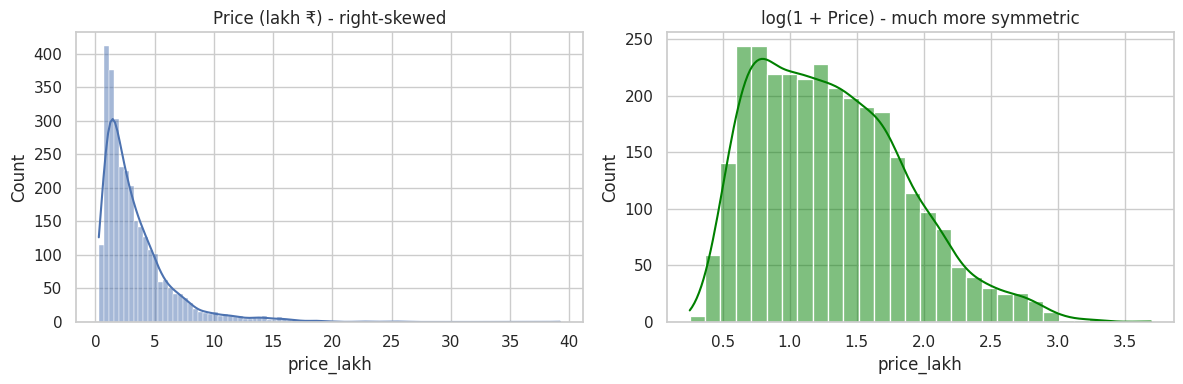

Skewness  raw: 2.74 | log: 0.63


In [4]:
# Target distribution: it is skewed, which justifies a log transform later
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], kde=True, ax=ax[0]).set_title("Price (lakh ₹) - right-skewed")
sns.histplot(np.log1p(df[TARGET]), kde=True, ax=ax[1], color="green").set_title("log(1 + Price) - much more symmetric")
plt.tight_layout(); plt.show()
print("Skewness  raw:", round(df[TARGET].skew(), 2), "| log:", round(np.log1p(df[TARGET]).skew(), 2))

**Finding:** Price is right-skewed (a few expensive luxury cars, many budget cars). A log transform makes the distribution roughly symmetric,
so we apply `log1p` to the target. This helps the models learn percentage-type errors and stops expensive cars from acting like outliers.

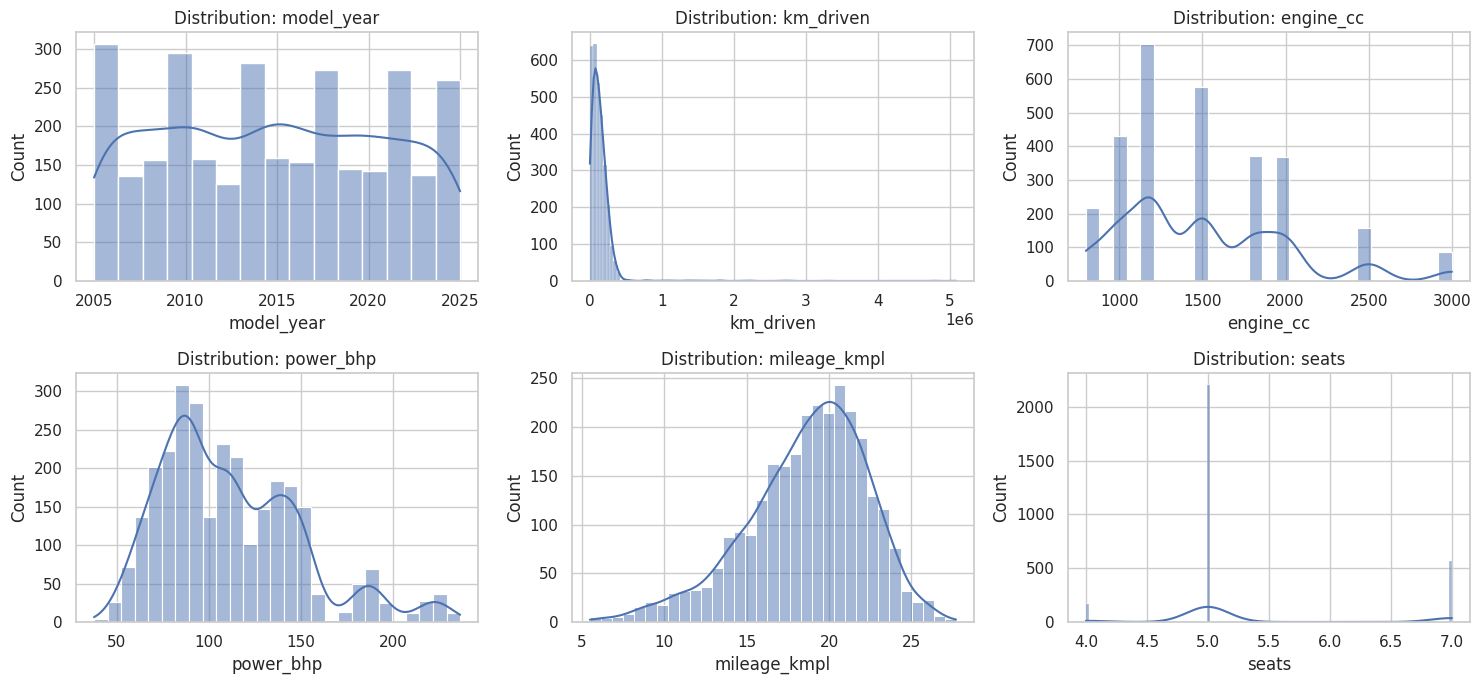

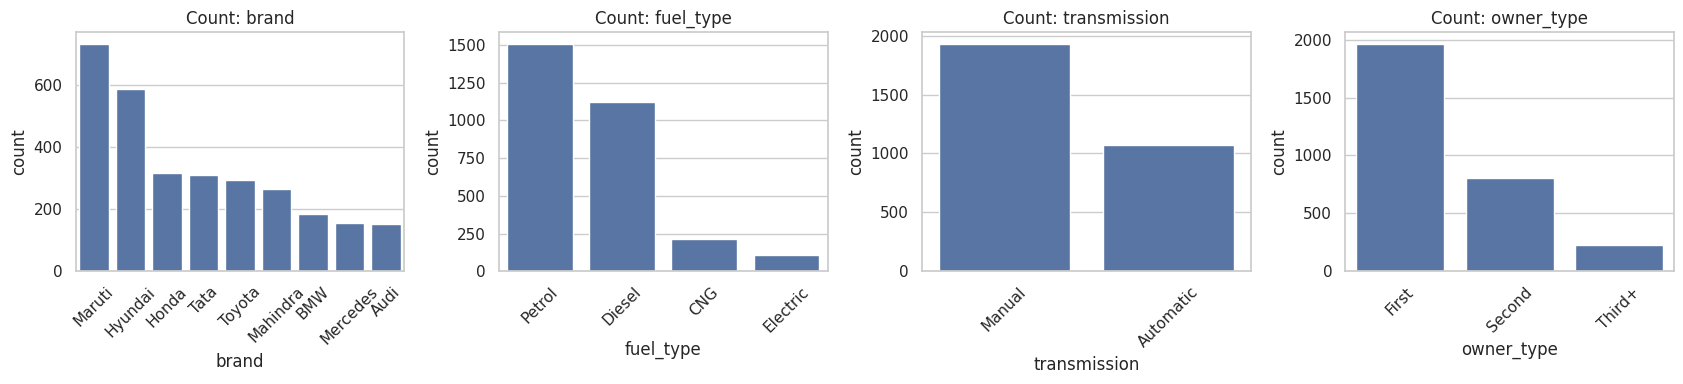

In [5]:
num_cols = ["model_year", "km_driven", "engine_cc", "power_bhp", "mileage_kmpl", "seats"]
cat_cols = ["brand", "fuel_type", "transmission", "owner_type"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=a); a.set_title(f"Distribution: {c}")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for a, c in zip(axes, cat_cols):
    order = df[c].value_counts().index
    sns.countplot(data=df, x=c, order=order, ax=a); a.set_title(f"Count: {c}")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

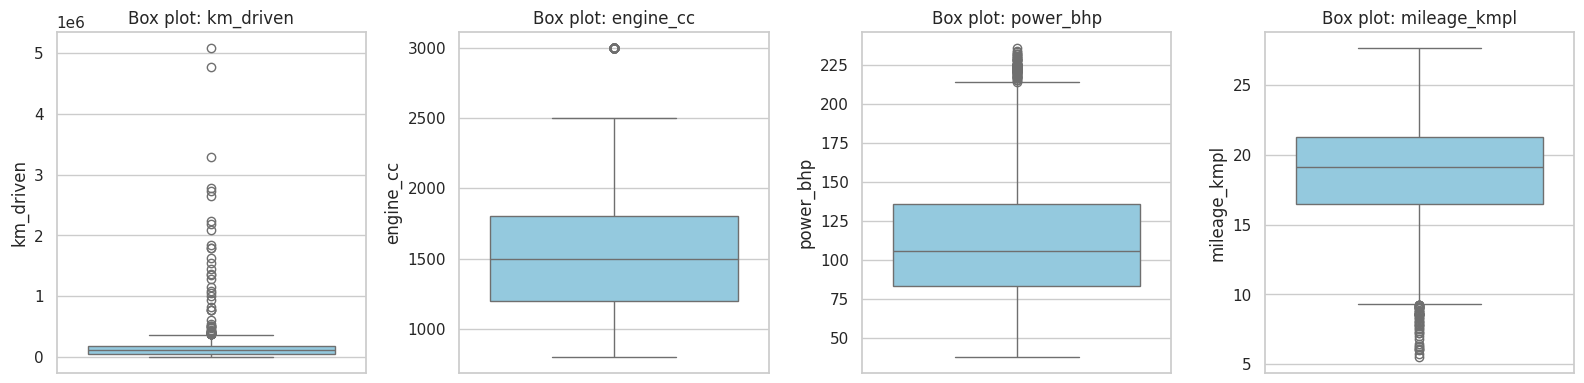

In [6]:
# Outlier detection with box plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for a, c in zip(axes, ["km_driven", "engine_cc", "power_bhp", "mileage_kmpl"]):
    sns.boxplot(y=df[c], ax=a, color="skyblue"); a.set_title(f"Box plot: {c}")
plt.tight_layout(); plt.show()

**Finding:** `km_driven` has a few extreme outliers (hundreds of thousands of km, which are practically data-entry errors).
We will **cap (winsorize)** them using the IQR method instead of deleting rows, so no data is lost.

### 2.2 Bivariate Analysis

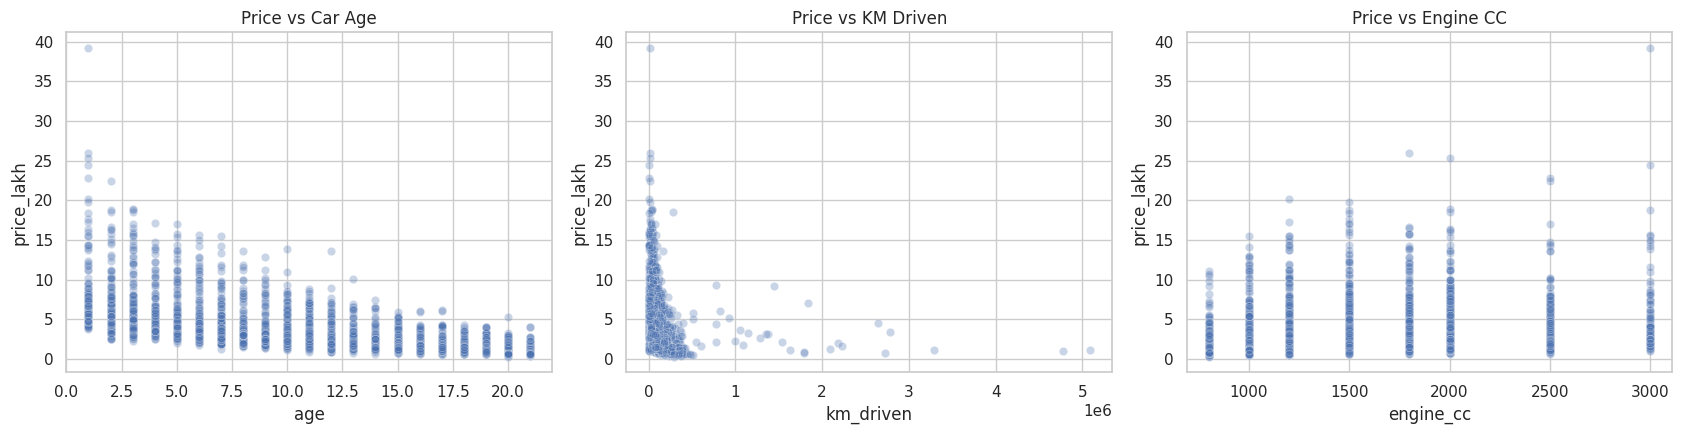

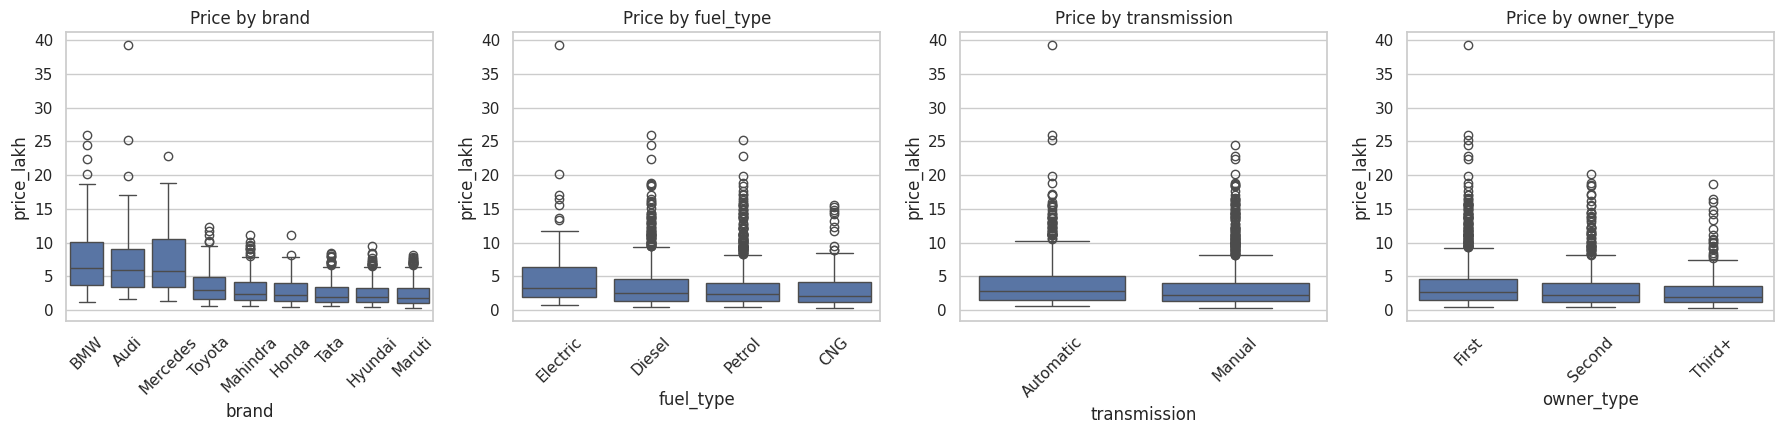

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=df.assign(age=2026 - df.model_year), x="age", y=TARGET, alpha=.3, ax=axes[0]).set_title("Price vs Car Age")
sns.scatterplot(data=df, x="km_driven", y=TARGET, alpha=.3, ax=axes[1]).set_title("Price vs KM Driven")
sns.scatterplot(data=df, x="engine_cc", y=TARGET, alpha=.3, ax=axes[2]).set_title("Price vs Engine CC")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for a, c in zip(axes, cat_cols):
    order = df.groupby(c)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=c, y=TARGET, order=order, ax=a); a.set_title(f"Price by {c}")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Findings:** The older the car, the lower the price. Premium brands (BMW, Audi, Mercedes) and automatic transmission clearly raise the price.
Larger engines cost more, and a higher owner count lowers the price.

### 2.3 Correlation Analysis

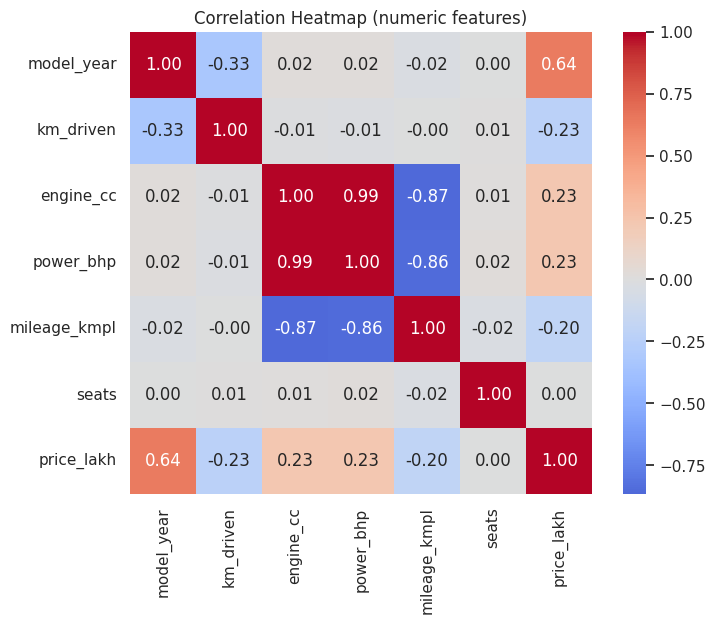

In [8]:
plt.figure(figsize=(8, 6))
corr = df[num_cols + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

**Finding:** `engine_cc` and `power_bhp` are strongly correlated (multicollinearity), which can be risky for Linear Regression.
That is one reason we also compare tree-based models. `model_year` is positively correlated with price (newer car, higher price).

## 3. Feature Engineering and Train/Test Split
- **Feature engineering** is row-wise (`car_age`, `km_per_year`). It uses no information from other rows, so it cannot leak data.
- **The split comes first.** Imputation values, outlier bounds and scaling statistics are all learned from the **training set only**.

In [9]:
def add_features(d):
    d = d.copy()
    d["car_age"] = 2026 - d["model_year"]
    d["km_per_year"] = d["km_driven"] / d["car_age"].clip(lower=1)
    return d.drop(columns=["model_year"])

data = add_features(df)
X = data.drop(columns=[TARGET])
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

num_features = ["km_driven", "engine_cc", "power_bhp", "mileage_kmpl", "seats", "car_age", "km_per_year"]
cat_features = ["brand", "fuel_type", "transmission", "owner_type"]

Train: (2400, 11) | Test: (600, 11)


## 4. Preprocessing Pipeline (Leakage-Free)
| Step | Technique | Why? |
|---|---|---|
| Missing numeric values | **Median** imputation | Robust to outliers (the mean gets distorted by them) |
| Missing categorical values | **Most-frequent** imputation | Natural choice for categorical data |
| Outliers | **IQR capping** (Q1 − 1.5·IQR, Q3 + 1.5·IQR) | Limits extreme values without deleting rows |
| Encoding | **One-Hot** (`handle_unknown="ignore"`) | Brand and fuel type have no natural order |
| Scaling | **StandardScaler** | Puts features on comparable scales for the linear model |

Everything lives inside a scikit-learn `Pipeline`, so `fit` only ever sees the training data and the test data is only transformed.

In [10]:
class IQRClipper(BaseEstimator, TransformerMixin):
    """Learns outlier bounds from the training data only, then clips both train and test."""
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_, self.upper_ = q1 - self.factor * iqr, q3 + self.factor * iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clip", IQRClipper(factor=1.5)),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Model Training and Comparison
Three distinct algorithms:
1. **Linear Regression**: a simple, interpretable baseline.
2. **Random Forest**: captures non-linear relationships and interactions, and is robust to outliers.
3. **Gradient Boosting**: builds trees sequentially and is often the most accurate on tabular data.

The target is log-transformed with `TransformedTargetRegressor` because price is skewed. Predictions are automatically converted back to ₹ lakh.
To keep the comparison fair, every model is also evaluated with **5-fold cross-validation** on the training data only.

In [11]:
def make_model(estimator):
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", preprocessor), ("model", estimator)]),
        func=np.log1p, inverse_func=np.expm1,
    )

models = {
    "Linear Regression": make_model(LinearRegression()),
    "Random Forest": make_model(RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                                       n_jobs=-1, random_state=RANDOM_STATE)),
    "Gradient Boosting": make_model(GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                                               max_depth=3, random_state=RANDOM_STATE)),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, preds = [], {}

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2").mean()
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    preds[name] = p
    results.append({
        "Model": name,
        "CV R² (train)": round(cv_r2, 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, p)), 4),
        "Test MAE": round(mean_absolute_error(y_test, p), 4),
        "Test R²": round(r2_score(y_test, p), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df

,CV R² (train),Test RMSE,Test MAE,Test R²
Model,,,,
Linear Regression,0.9374,0.4549,0.3016,0.9680
Random Forest,0.9014,0.6796,0.4299,0.9286
Gradient Boosting,0.9578,0.4810,0.2864,0.9642


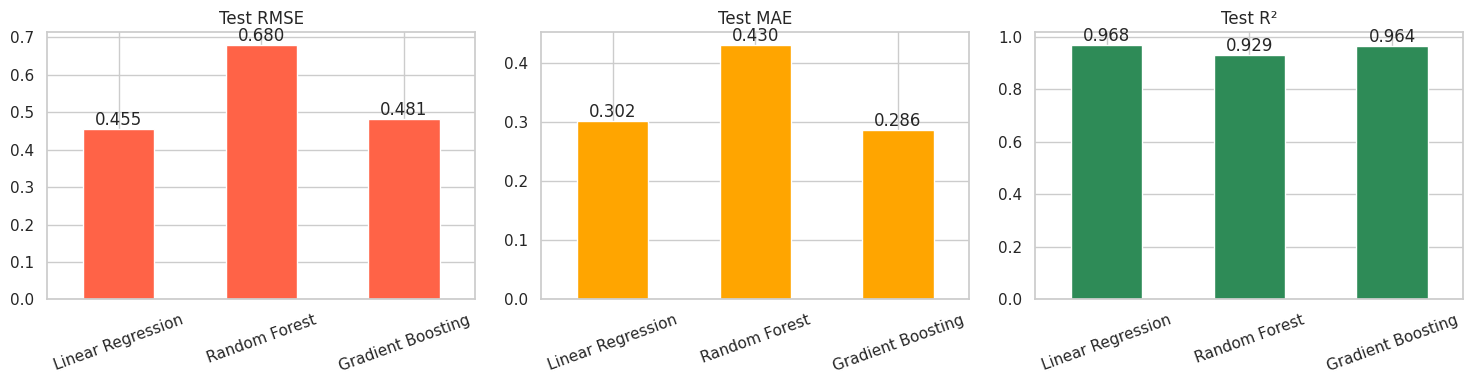

Best model (highest test R²): Linear Regression


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for a, (metric, color) in zip(axes, [("Test RMSE", "tomato"), ("Test MAE", "orange"), ("Test R²", "seagreen")]):
    results_df[metric].plot(kind="bar", ax=a, color=color)
    a.set_title(metric); a.set_xlabel(""); a.tick_params(axis="x", rotation=20)
    for i, v in enumerate(results_df[metric]):
        a.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

best_name = results_df["Test R²"].idxmax()
print(f"Best model (highest test R²): {best_name}")

**Interpretation:** RMSE and MAE are in ₹ lakh (lower is better); R² closer to 1 means a more accurate model.
An interesting result: **after the log transform, plain Linear Regression is also very strong**, because the relationship between price and
age/engine size is multiplicative (so it becomes linear in log space). Gradient Boosting has the lowest MAE and the highest cross-validation R²
(smaller typical errors), while Linear Regression has the lowest RMSE (fewer large errors). Random Forest comes last, partly because trees cannot
extrapolate beyond the value ranges they have seen. Read the table above and choose the best model based on your own run.

## 6. Error Analysis of the Best Model

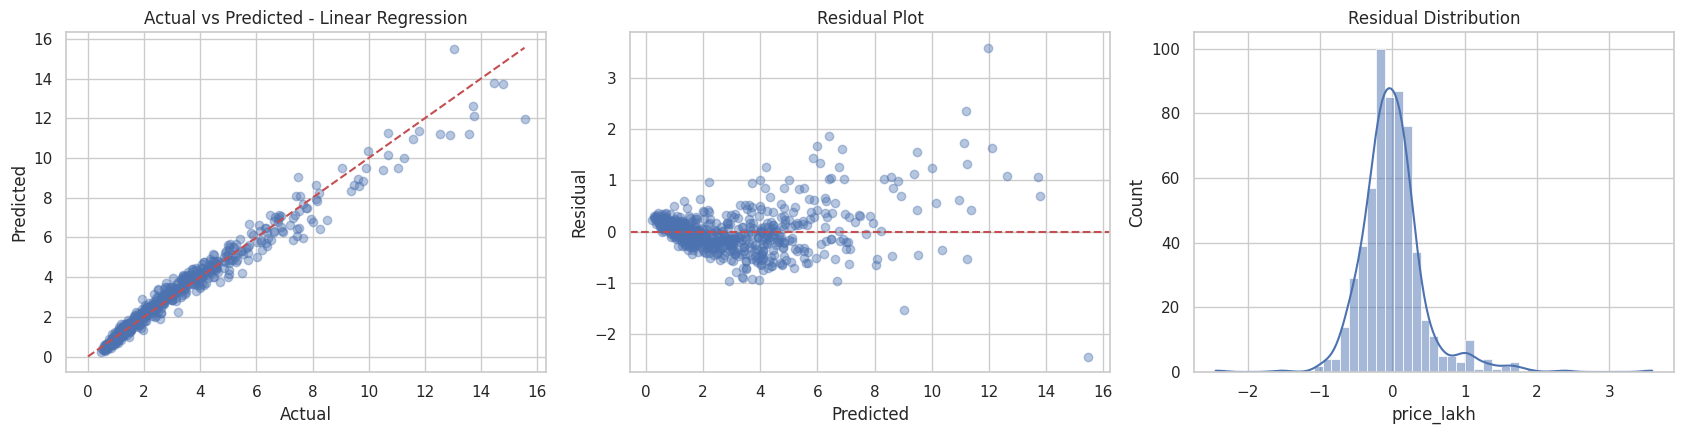

In [13]:
best_pred = preds[best_name]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].scatter(y_test, best_pred, alpha=.4)
lims = [0, max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, "r--"); axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted - {best_name}")

axes[1].scatter(best_pred, residuals, alpha=.4); axes[1].axhline(0, color="r", ls="--")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residual Plot")

sns.histplot(residuals, kde=True, ax=axes[2]); axes[2].set_title("Residual Distribution")
plt.tight_layout(); plt.show()

**What to look for:** Residuals should scatter randomly around zero with no clear pattern. If the error grows for high-priced cars, that is normal,
because expensive cars naturally have more price variability.

## 7. Feature Importance (Permutation)
Permutation importance shuffles one feature at a time and measures how much the model's score drops, which shows how much the model relies on that feature.
It is computed on the raw (pre-encoding) columns, so the result is easy to interpret.

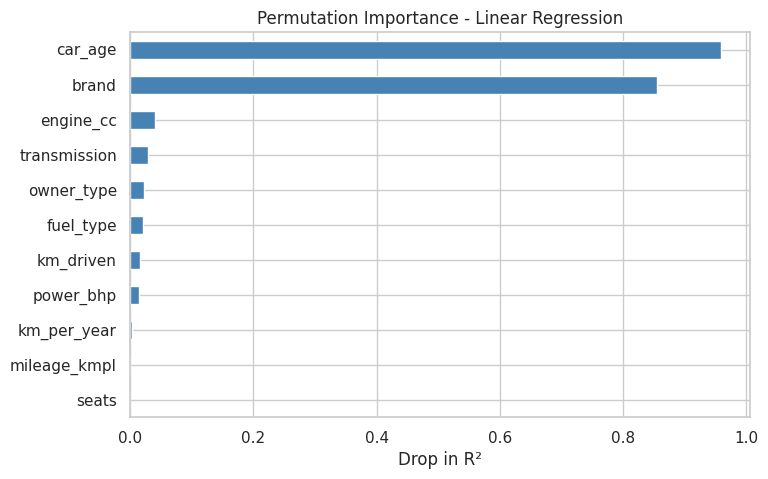

In [14]:
best_model = models[best_name]
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring="r2")
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

imp.plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title(f"Permutation Importance - {best_name}"); plt.xlabel("Drop in R²")
plt.show()

## 8. Conclusion
- **Data cleaning:** missing values (median / most frequent), outliers (IQR capping), categoricals (One-Hot), scaling (StandardScaler), all in one `Pipeline`.
- **Leakage prevention:** the split happens first, preprocessing is fitted on the training set only, and feature engineering is row-wise.
- **Best model:** see the comparison table above. With a log-transformed target, simple Linear Regression gave a strong baseline, and Gradient Boosting performed best on MAE and cross-validation.
  The lesson: start with a simple baseline, then compare more complex models against it.
- **Key drivers:** the feature importance plot shows which features (such as car age, brand, engine size and transmission) matter most for price.

**Future improvements:** hyperparameter tuning with `GridSearchCV` / `RandomizedSearchCV`, trying XGBoost or LightGBM, and retraining on a real dataset (for example Kaggle *Used Cars*).

## 9. Predict the Price of a New Car
Enter the details of any car in `predict_car()` below (brands: Audi, BMW, Honda, Hyundai, Mahindra, Maruti, Mercedes, Tata, Toyota).
The same feature engineering used in training is applied, and the preprocessing pipeline is part of the model, so raw details are enough.

In [15]:
def predict_car(brand, model_year, fuel_type, transmission, owner_type,
                km_driven, engine_cc, power_bhp, mileage_kmpl, seats, model=None):
    """Takes the details of one car and returns the predicted price in lakh Rs."""
    model = model or best_model
    row = pd.DataFrame([{
        "brand": brand, "model_year": model_year, "fuel_type": fuel_type,
        "transmission": transmission, "owner_type": owner_type,
        "km_driven": km_driven, "engine_cc": engine_cc, "power_bhp": power_bhp,
        "mileage_kmpl": mileage_kmpl, "seats": seats,
    }])
    row = add_features(row)[X.columns]      # same feature engineering as in training
    return float(model.predict(row)[0])     # the log-transform inverse is applied automatically

# ---- Change the values below to your own car ----
price = predict_car(brand="Toyota", model_year=2020, fuel_type="Diesel",
                    transmission="Automatic", owner_type="First", km_driven=30000,
                    engine_cc=2000, power_bhp=148, mileage_kmpl=14, seats=7)
print(f"Predicted price: Rs {price:.2f} lakh")

Predicted price: Rs 6.95 lakh
